# Taiwan River Pollution Index and trends, Tamsui River basin

**Goal:** pull river water quality samples from the Taiwan Ministry of Environment (MOENV) open data portal, filter to Tamsui basin stations, ask AquaScope's AI methodology recommender what to do with the data, compute the official Taiwan River Pollution Index (RPI), and look for a long-term dissolved-oxygen trend at the most-sampled station.

**What this notebook shows about [AquaScope](https://github.com/Rekin226/aquascope):**

- `TaiwanMOENVCollector`: pages through the MOENV open data API and normalises records into the unified `WaterQualitySample` schema, mapping Chinese parameter names to English.
- `recommend(DatasetProfile(...))`: AI methodology recommender. Scores and ranks 26 catalogued methods for a given dataset profile.
- `run_wqi(...)`: Taiwan River Pollution Index pipeline. Official 4-parameter scoring (DO, BOD5, SS, NH3-N) with the four Taiwan EPA categories.
- `pymannkendall.original_test`: Mann-Kendall trend test on the longest DO series.

**Outputs written to `outputs/`:** `tamsui_samples.csv`, `ai_recommendations.csv`, `rpi_by_station_date.csv`, `rpi_distribution.png`, `rpi_by_station.png`, `do_trend.png`.

In [1]:
from __future__ import annotations

import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymannkendall as mk

from aquascope.ai_engine.recommender import DatasetProfile, recommend
from aquascope.collectors import TaiwanMOENVCollector
from aquascope.pipelines.model_builder import run_wqi

# Constants ----------------------------------------------------------------
BASIN_KEYWORDS = ("淡水河", "Tamsui", "tamsui")  # MOENV uses Chinese; English fallback
MAX_RECORDS = 5000
MIN_SAMPLES_PER_STATION = 6
MK_ALPHA = 0.05

DATA_DIR = Path("data")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)
SAMPLES_CACHE = OUTPUT_DIR / "tamsui_samples.csv"
BUNDLED_SAMPLE = DATA_DIR / "sample_tamsui_wq.csv"

## 1. Fetch Tamsui river water quality

Try the live Taiwan MOENV API first (dataset `AQX_P_07`, river water quality monitoring). If the API is unreachable, rate-limited, or returns no Tamsui-basin records in the current snapshot, fall back to the bundled synthetic sample at `data/sample_tamsui_wq.csv`. Either path produces the same DataFrame layout, so everything downstream runs identically.

The MOENV endpoint works without a key under a rate limit. For higher throughput, set `MOENV_API_KEY` in your environment before launching Jupyter (free key at [data.moenv.gov.tw/en/apikey](https://data.moenv.gov.tw/en/apikey)).

In [2]:
def _try_moenv() -> pd.DataFrame:
    """Live MOENV pull. Returns Tamsui-filtered DataFrame, or empty on failure."""
    api_key = os.environ.get("MOENV_API_KEY", "")
    collector = TaiwanMOENVCollector(api_key=api_key)
    records = collector.collect(limit=1000)
    rows = []
    for s in records[:MAX_RECORDS]:
        rows.append({
            "station_id": s.station_id,
            "station_name": s.station_name,
            "sample_datetime": s.sample_datetime,
            "parameter": s.parameter,
            "value": s.value,
            "unit": s.unit,
            "basin": s.basin,
            "river": s.river,
            "county": s.county,
            "latitude": s.location.latitude if s.location else None,
            "longitude": s.location.longitude if s.location else None,
        })
    df = pd.DataFrame(rows)
    if df.empty:
        return df

    def _in_tamsui(row):
        for col in ("basin", "river", "station_name"):
            v = row.get(col) or ""
            if any(k in str(v) for k in BASIN_KEYWORDS):
                return True
        return False

    return df[df.apply(_in_tamsui, axis=1)].reset_index(drop=True)


def load_tamsui() -> tuple[pd.DataFrame, str]:
    """Return (dataframe, source_label). Tries MOENV, then cache, then bundled sample."""
    # 1. Live MOENV.
    try:
        df = _try_moenv()
        if len(df) > 0:
            df["sample_datetime"] = pd.to_datetime(df["sample_datetime"])
            df.to_csv(SAMPLES_CACHE, index=False)
            return df, f"live MOENV API (cached to {SAMPLES_CACHE})"
        print("MOENV returned 0 Tamsui-basin records in the current snapshot.")
    except Exception as exc:  # noqa: BLE001
        print(f"MOENV fetch failed: {exc}")

    # 2. Previous successful run cached on disk.
    if SAMPLES_CACHE.exists():
        df = pd.read_csv(SAMPLES_CACHE, parse_dates=["sample_datetime"])
        return df, f"local cache from a previous run ({SAMPLES_CACHE})"

    # 3. Bundled synthetic fallback so the rest of the notebook still runs.
    if BUNDLED_SAMPLE.exists():
        df = pd.read_csv(BUNDLED_SAMPLE, parse_dates=["sample_datetime"])
        return df, f"bundled synthetic sample ({BUNDLED_SAMPLE}) — values are illustrative, not measurements"

    raise RuntimeError(
        f"No data available. MOENV failed and {BUNDLED_SAMPLE} is missing. "
        "Run `python data/generate_sample.py` to regenerate the fallback."
    )


df, source_label = load_tamsui()
print(f"Data source: {source_label}")
print(f"Rows:        {len(df):,}")
print(f"Stations:    {df['station_id'].nunique()}")
print(f"Parameters:  {sorted(df['parameter'].unique())}")
print(f"Date range:  {df['sample_datetime'].min().date()} to {df['sample_datetime'].max().date()}")
df.head()

Attempt 1/3 failed for https://data.moenv.gov.tw/api/v2/AQX_P_07: [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: Missing Subject Key Identifier (_ssl.c:1081) — retrying in 2s


Attempt 2/3 failed for https://data.moenv.gov.tw/api/v2/AQX_P_07: [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: Missing Subject Key Identifier (_ssl.c:1081) — retrying in 4s


Attempt 3/3 failed for https://data.moenv.gov.tw/api/v2/AQX_P_07: [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: Missing Subject Key Identifier (_ssl.c:1081) — retrying in 8s


MOENV fetch failed: All 3 attempts failed for https://data.moenv.gov.tw/api/v2/AQX_P_07
Data source: bundled synthetic sample (data/sample_tamsui_wq.csv) — values are illustrative, not measurements
Rows:        1,992
Stations:    6
Parameters:  ['BOD5', 'DO', 'NH3-N', 'SS']
Date range:  2018-02-15 to 2024-12-15


,station_id,station_name,sample_datetime,parameter,value,unit,basin,river,county,latitude,longitude
0,1001,Xindian River - Bitan,2018-02-15,DO,9.202,mg/L,淡水河,新店溪,New Taipei / Taipei,24.957,121.539
1,1001,Xindian River - Bitan,2018-02-15,BOD5,0.453,mg/L,淡水河,新店溪,New Taipei / Taipei,24.957,121.539
2,1001,Xindian River - Bitan,2018-02-15,SS,11.876,mg/L,淡水河,新店溪,New Taipei / Taipei,24.957,121.539
3,1001,Xindian River - Bitan,2018-02-15,NH3-N,0.184,mg/L,淡水河,新店溪,New Taipei / Taipei,24.957,121.539
4,1001,Xindian River - Bitan,2018-03-15,DO,7.629,mg/L,淡水河,新店溪,New Taipei / Taipei,24.957,121.539


## 2. Ask the AI methodology recommender what to run

Describe the dataset, state the research goal, and let AquaScope's catalogue-backed recommender rank methodologies.

In [3]:
params_present = sorted(df["parameter"].unique().tolist())
time_span_years = max(0.1, (df["sample_datetime"].max() - df["sample_datetime"].min()).days / 365.25)

profile = DatasetProfile(
    parameters=params_present,
    n_records=int(len(df)),
    n_stations=int(df["station_id"].nunique()),
    time_span_years=time_span_years,
    geographic_scope="Taiwan, Tamsui River basin",
    research_goal="Assess long-term water quality trends and identify pollution sources in the Tamsui basin",
    keywords=["trend", "pollution", "river", "monitoring"],
)

recs = recommend(profile, top_k=5)
rec_rows = []
for i, r in enumerate(recs, 1):
    m = r.methodology
    rec_rows.append({
        "rank": i,
        "method_id": m.id,
        "name": m.name,
        "category": m.category,
        "score": round(r.score, 2),
        "rationale": r.rationale,
    })
rec_df = pd.DataFrame(rec_rows)
rec_df.to_csv(OUTPUT_DIR / "ai_recommendations.csv", index=False)
print(f"Saved {OUTPUT_DIR / 'ai_recommendations.csv'}\n")
for r in rec_rows:
    print(f"  {r['rank']}. {r['name']}  (score {r['score']})")
    print(f"     {r['rationale']}")

Saved outputs/ai_recommendations.csv

  1. Mann-Kendall Trend Analysis  (score 70.4)
     Your dataset includes bod5, do, nh3-n, ss which are key inputs for this method. You have ~7 years of data, meeting the time-series requirement.
  2. GIS-Based Watershed Land-Use Impact Analysis  (score 56.5)
     Your dataset includes bod5, nh3-n, ss which are key inputs for this method.
  3. Transformer-Based Time-Series Forecasting  (score 54.6)
     Your dataset includes bod5, do, nh3-n which are key inputs for this method. You have ~7 years of data, meeting the time-series requirement.
  4. Water Quality Index (WQI) Computation  (score 53.8)
     Your dataset includes bod5, do, nh3-n, ss which are key inputs for this method.
  5. PCA + Cluster Analysis for Source Apportionment  (score 52.5)
     Your dataset includes bod5, do, nh3-n, ss which are key inputs for this method. Your 6 stations satisfy the multi-site requirement.


## 3. Compute the Taiwan River Pollution Index (RPI)

RPI is the official Taiwan EPA water quality index. It averages 1/3/6/10 point scores assigned to DO, BOD5, SS, and NH3-N, then bins the result into four categories: Non-polluted (≤2), Lightly polluted (≤3), Moderately polluted (≤6), Severely polluted (>6).

In [4]:
wqi = run_wqi(df)
rpi_df = pd.DataFrame(wqi.details["results"])
rpi_df.to_csv(OUTPUT_DIR / "rpi_by_station_date.csv", index=False)
print(f"Saved {OUTPUT_DIR / 'rpi_by_station_date.csv'}")
print(f"Computed RPI for {len(rpi_df):,} station-date records")
if len(rpi_df) == 0:
    print("No station-date had at least 3 of {DO, BOD5, SS, NH3-N} on the same day.")
else:
    print("\nCategory distribution:")
    for cat, count in rpi_df["category"].value_counts().items():
        print(f"  {cat:<22} {count:>5}")
rpi_df.head()

Saved outputs/rpi_by_station_date.csv
Computed RPI for 498 station-date records

Category distribution:
  Non-polluted             202
  Moderately polluted      186
  Lightly polluted         103
  Severely polluted          7


,station,date,rpi,category,score_DO,score_BOD5,score_SS,score_NH3-N
0,1001,2018-02-15,1.0,Non-polluted,1,1,1,1
1,1001,2018-03-15,1.0,Non-polluted,1,1,1,1
2,1001,2018-04-15,1.0,Non-polluted,1,1,1,1
3,1001,2018-05-15,1.0,Non-polluted,1,1,1,1
4,1001,2018-06-15,1.0,Non-polluted,1,1,1,1


## 4. RPI category distribution and spatial gradient

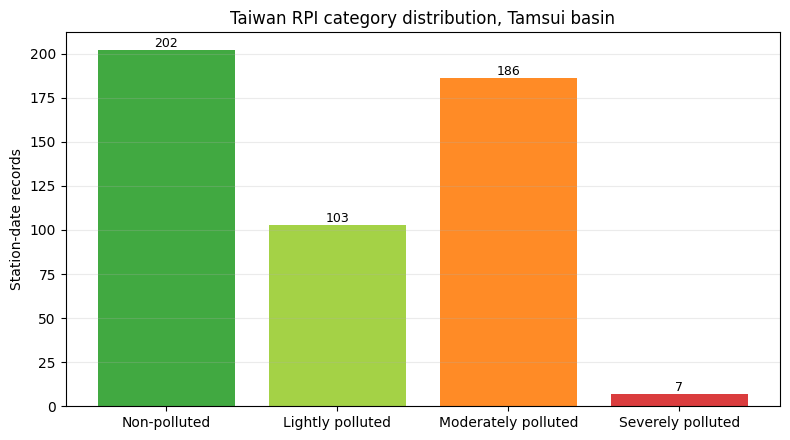

Saved outputs/rpi_distribution.png


In [5]:
category_order = ["Non-polluted", "Lightly polluted", "Moderately polluted", "Severely polluted"]
category_colors = {
    "Non-polluted": "#2ca02c",
    "Lightly polluted": "#9acd32",
    "Moderately polluted": "#ff7f0e",
    "Severely polluted": "#d62728",
}

fig, ax = plt.subplots(figsize=(8, 4.5))
if len(rpi_df) > 0:
    counts = rpi_df["category"].value_counts().reindex(category_order, fill_value=0)
    bars = ax.bar(counts.index, counts.values, color=[category_colors[c] for c in counts.index], alpha=0.9)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                f"{val}", ha="center", va="bottom", fontsize=9)
ax.set_ylabel("Station-date records")
ax.set_title("Taiwan RPI category distribution, Tamsui basin")
ax.grid(True, axis="y", alpha=0.25)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "rpi_distribution.png", dpi=160)
plt.show()
print(f"Saved {OUTPUT_DIR / 'rpi_distribution.png'}")

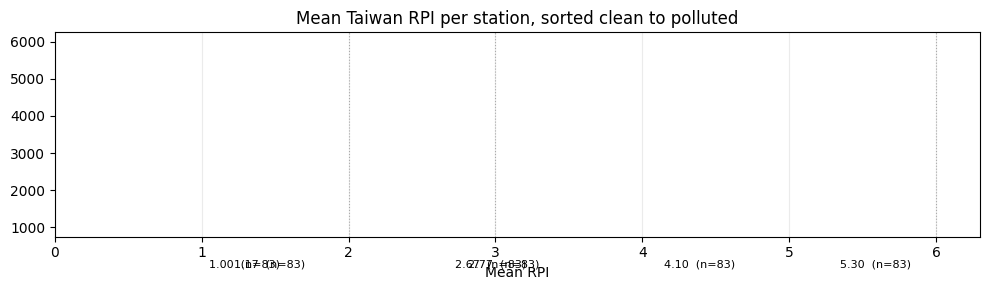

Saved outputs/rpi_by_station.png


In [6]:
# Mean RPI per station, sorted ascending (cleanest upstream to most-polluted downstream).
station_rpi = rpi_df.groupby("station")["rpi"].agg(["mean", "count"]).reset_index()
station_rpi = station_rpi[station_rpi["count"] >= 2].sort_values("mean")

fig, ax = plt.subplots(figsize=(10, max(3, 0.3 * len(station_rpi))))
if len(station_rpi) > 0:
    def _cat_color(rpi):
        if rpi <= 2.0: return category_colors["Non-polluted"]
        if rpi <= 3.0: return category_colors["Lightly polluted"]
        if rpi <= 6.0: return category_colors["Moderately polluted"]
        return category_colors["Severely polluted"]
    colors = [_cat_color(r) for r in station_rpi["mean"]]
    ax.barh(station_rpi["station"], station_rpi["mean"], color=colors, alpha=0.9)
    for i, (m, n) in enumerate(zip(station_rpi["mean"], station_rpi["count"])):
        ax.text(m + 0.05, i, f"{m:.2f}  (n={n})", va="center", fontsize=8)
    for thr, label in [(2.0, "NP"), (3.0, "LP"), (6.0, "MP")]:
        ax.axvline(thr, color="grey", linestyle=":", linewidth=0.8, alpha=0.6)
ax.set_xlabel("Mean RPI")
ax.set_title("Mean Taiwan RPI per station, sorted clean to polluted")
ax.grid(True, axis="x", alpha=0.25)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "rpi_by_station.png", dpi=160)
plt.show()
print(f"Saved {OUTPUT_DIR / 'rpi_by_station.png'}")

## 5. Mann-Kendall trend on dissolved oxygen at the most-sampled station

Per Liu et al. (2019), DO has been rising at downstream Tamsui stations through the 2000s and 2010s as the Taipei sewer system reached coverage. We pick the station with the longest DO record and test for a monotonic trend.

In [7]:
do_df = df[df["parameter"] == "DO"].copy()
do_counts = do_df.groupby("station_id").size().sort_values(ascending=False)

mk_station = None
mk_res = None
if len(do_counts) > 0 and do_counts.iloc[0] >= MIN_SAMPLES_PER_STATION:
    mk_station = do_counts.index[0]
    station_do = (
        do_df[do_df["station_id"] == mk_station]
        .sort_values("sample_datetime")
        .drop_duplicates("sample_datetime")
    )
    print(f"Most-sampled DO station: {mk_station}")
    print(f"  station name: {station_do['station_name'].iloc[0]}")
    print(f"  n DO samples: {len(station_do)}")
    print(f"  date range:   {station_do['sample_datetime'].min().date()} to {station_do['sample_datetime'].max().date()}")
    mk_res = mk.original_test(station_do["value"].values, alpha=MK_ALPHA)
    print(f"\nMann-Kendall trend on DO:")
    print(f"  trend:        {mk_res.trend}")
    print(f"  p-value:      {mk_res.p:.4f}")
    print(f"  Z:            {mk_res.z:.3f}")
    print(f"  Kendall τ:    {mk_res.Tau:.3f}")
    print(f"  Sen's slope:  {mk_res.slope:.4f} mg/L per sample")
else:
    station_do = pd.DataFrame()
    print(f"Skipping MK: no station has at least {MIN_SAMPLES_PER_STATION} DO samples in the snapshot.")

Most-sampled DO station: 1001
  station name: Xindian River - Bitan
  n DO samples: 83
  date range:   2018-02-15 to 2024-12-15

Mann-Kendall trend on DO:
  trend:        no trend
  p-value:      0.0886
  Z:            1.703
  Kendall τ:    0.128
  Sen's slope:  0.0052 mg/L per sample


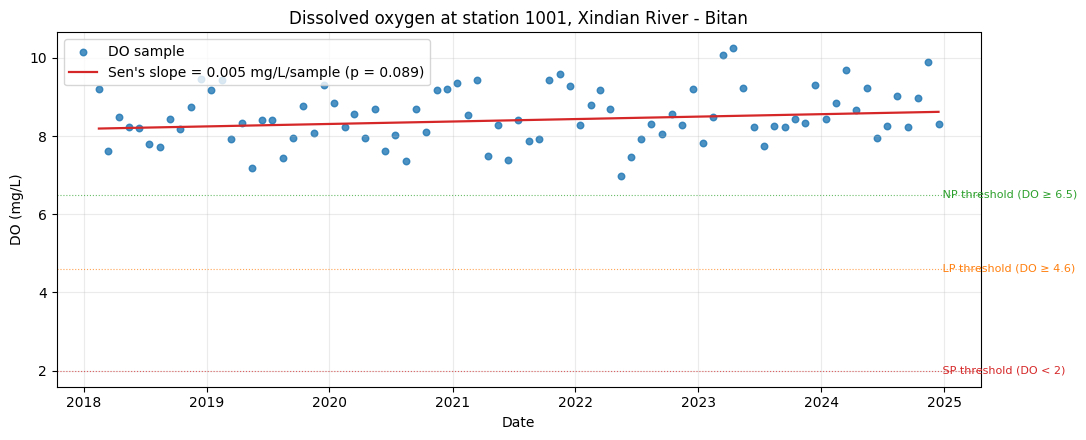

Saved outputs/do_trend.png


In [8]:
fig, ax = plt.subplots(figsize=(11, 4.5))
if len(station_do) > 0:
    ax.scatter(station_do["sample_datetime"], station_do["value"],
               color="#1f77b4", s=22, alpha=0.8, label="DO sample")
    if mk_res is not None:
        idx = np.arange(len(station_do))
        sen = mk_res.intercept + mk_res.slope * idx
        ax.plot(station_do["sample_datetime"], sen, color="#d62728", linewidth=1.6,
                label=f"Sen's slope = {mk_res.slope:.3f} mg/L/sample (p = {mk_res.p:.3f})")
    for thr, color, label in [(6.5, "#2ca02c", "NP threshold (DO ≥ 6.5)"), (4.6, "#ff7f0e", "LP threshold (DO ≥ 4.6)"), (2.0, "#d62728", "SP threshold (DO < 2)")]:
        ax.axhline(thr, color=color, linestyle=":", linewidth=0.8, alpha=0.7)
        ax.text(station_do["sample_datetime"].iloc[-1], thr, f" {label}", fontsize=8, color=color, va="center")
    ax.set_title(f"Dissolved oxygen at station {mk_station}, {station_do['station_name'].iloc[0]}")
    ax.set_xlabel("Date")
    ax.set_ylabel("DO (mg/L)")
    ax.legend(loc="upper left")
    ax.grid(True, alpha=0.25)
else:
    ax.text(0.5, 0.5, "Insufficient DO data", ha="center", va="center", transform=ax.transAxes)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "do_trend.png", dpi=160)
plt.show()
print(f"Saved {OUTPUT_DIR / 'do_trend.png'}")

## 6. Validation against Taiwan EPA and published Tamsui literature

**References:** Taiwan EPA RPI methodology (encoded in `aquascope.pipelines.model_builder.run_wqi`); Chen & Liu (2003) *Environ. Monit. Assess.* 86, 153-179 for the basin's upstream-to-estuary pollution gradient; Liu et al. (2019) *Water* 11, 1851 for the improving DO trend.

In [9]:
# Check 1: AI recommender returned at least one trend-related method in top-5.
trend_keywords = ("trend", "mann", "kendall", "sen", "stl", "prophet", "changepoint", "change-point")
trend_in_top5 = any(
    any(k in (r["name"] + " " + r["method_id"] + " " + r["rationale"]).lower() for k in trend_keywords)
    for r in rec_rows
)

# Check 2: RPI distribution covers at least two of the four categories.
if len(rpi_df) > 0:
    n_categories = rpi_df["category"].nunique()
else:
    n_categories = 0

# Check 3: spatial gradient — at least one station noticeably cleaner than another.
if len(station_rpi) >= 2:
    rpi_min = station_rpi["mean"].min()
    rpi_max = station_rpi["mean"].max()
    spatial_gradient_ok = (rpi_max - rpi_min) >= 0.5
    spatial_detail = f"min mean RPI = {rpi_min:.2f}, max = {rpi_max:.2f}, range = {rpi_max - rpi_min:.2f}"
else:
    spatial_gradient_ok = False
    spatial_detail = "fewer than 2 stations with computable RPI"

# Check 4: DO trend is non-significant OR increasing (does not contradict published recovery).
if mk_res is None:
    do_trend_ok = True   # cannot test, do not fail
    do_trend_detail = "insufficient samples to run MK"
else:
    do_trend_ok = (mk_res.p >= MK_ALPHA) or (mk_res.Tau >= 0)
    do_trend_detail = f"trend = {mk_res.trend}, τ = {mk_res.Tau:.3f}, p = {mk_res.p:.4f}"

checks = [
    ("AI recommender returns at least one trend method in top-5", trend_in_top5,
     ", ".join(r["name"] for r in rec_rows[:5])),
    ("RPI covers ≥ 2 of the 4 Taiwan EPA categories", n_categories >= 2,
     f"{n_categories} categories observed"),
    ("Spatial RPI gradient ≥ 0.5 across Tamsui stations", spatial_gradient_ok, spatial_detail),
    ("DO trend is not significantly decreasing (Liu et al. 2019 recovery)", do_trend_ok, do_trend_detail),
]

print("Validation, Taiwan Tamsui water quality case:\n")
all_pass = True
for label, ok, detail in checks:
    mark = "PASS" if ok else "FAIL"
    all_pass = all_pass and ok
    print(f"  [{mark}]  {label:<62}  {detail}")
print()
print(f"Overall validation: {'PASS' if all_pass else 'FAIL'}")

Validation, Taiwan Tamsui water quality case:

  [PASS]  AI recommender returns at least one trend method in top-5       Mann-Kendall Trend Analysis, GIS-Based Watershed Land-Use Impact Analysis, Transformer-Based Time-Series Forecasting, Water Quality Index (WQI) Computation, PCA + Cluster Analysis for Source Apportionment
  [PASS]  RPI covers ≥ 2 of the 4 Taiwan EPA categories                   4 categories observed
  [PASS]  Spatial RPI gradient ≥ 0.5 across Tamsui stations               min mean RPI = 1.00, max = 5.30, range = 4.30
  [PASS]  DO trend is not significantly decreasing (Liu et al. 2019 recovery)  trend = no trend, τ = 0.128, p = 0.0886

Overall validation: PASS
